# Сессионное задание: Диффузионные модели

**План задания** (суммарно **50 баллов**)

1. **2D-датасет SwissRoll** (суммарно **40 баллов**)
    1. Реализовать прямой и обратный процессы диффузии и обучить базовый DDPM. (20 баллов)
    2. Реализовать classifier-free guidance. (10 баллов)
    3. Реализовать ускоренный семплинг. (10 баллов)

2. **Датасет MNIST** (суммарно **10 баллов**)
    1. Визуализировать прямой диффузионный процесс. (1 балл)
    2. Обучить диффузионную модель с визуально хорошим качеством генерации. (7 баллов)
    3. Сравнить генерации с помощью classifier-free guidance для разных значений guidance scale. (2 балла)

Ваша задача — заполнить пропуски внутри блоков с подписью `ваш код`.


Если вы работаете в `Google Colab`, нужно, чтобы Python «видел» дополнительный файл `utils.py`, который приложен к заданию:

1. Загрузите файл `utils.py` на ваш Google Drive.
2. Раскомментируйте код ниже.
3. Укажите в переменной `path` путь к файлу `utils.py` на вашем Google Drive.


In [ ]:
import os
import re
import random

import numpy as np
import seaborn as sns
import torch
import torch as th
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.utils import shuffle
from tqdm import tqdm
from copy import deepcopy
from typing import Optional, Tuple, List

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_root = '/content/drive/MyDrive/papadyk-collab/diffusion'
output_dir = os.path.join(drive_root, 'output')
utils_path = os.path.join(drive_root, 'utils.py')
!cp $utils_path .

from utils import get_labeled_data_loader, MyUNet

Mounted at /content/drive


## DDPM

В этой части мы реализуем свою собственную модель (DDPM) и применим её на датасете SwissRoll.

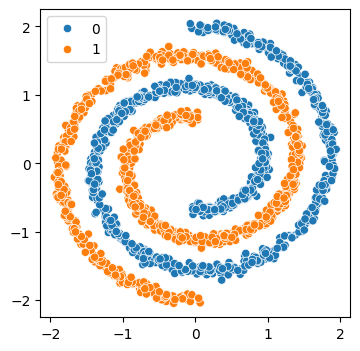

In [ ]:
def make_swiss_dataset(num_samples):
    X0, _ = make_swiss_roll(num_samples // 2, noise=0.3, random_state=0)
    X1, _ = make_swiss_roll(num_samples // 2, noise=0.3, random_state=0)
    X0 = X0[:, [0, 2]]
    X1 = X1[:, [0, 2]]
    X1 = -X1
    X, y = shuffle(
        np.concatenate([X0, X1], axis=0),
        np.concatenate([np.zeros(len(X0)), np.ones(len(X1))], axis=0),
        random_state=0)
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    return X, y

X, y = make_swiss_dataset(2000)
y = y.astype(int)

plt.figure(figsize=(4, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y);

**Кратко повторим теорию диффузионных моделей.**

Диффузионная модель состоит из прямого и обратного процессов.

Прямой процесс задаётся условным распределением $q(x_{1:T} \mid x_0)$.

Это марковская цепь, которая последовательно добавляет гауссовский шум к исходному объекту $x_0$.

На каждом шаге добавляется шум некоторой величины, которая определяется расписанием дисперсий $\{\beta_1, \ldots, \beta_T\}$.

Если это расписание выбрано правильно и $T$ стремится к бесконечности (или достаточно велико), процесс сходится к стандартному гауссовскому распределению $\mathscr{N}(0, I)$.

Распределения $q$ имеют следующий вид:
$$
 q(x_t \mid x_{t - 1}) := \mathscr{N}(x_t; \sqrt{1 - \beta_t}\,x_{t - 1}, \beta_t I),
 \qquad
 q(x_{1:T}\mid x_0) = \prod_{t = 1}^T q(x_t \mid x_{t - 1}).
$$

Теперь рассмотрим обратный процесс.

Обратный процесс последовательно удаляет шум, начиная с чистого гауссовского шума, до тех пор, пока не будет получен объект из исходного распределения.

Таким образом, диффузионная модель является вероятностной моделью с латентными переменными
$p_\theta(x_0) := \int p_\theta(x_{0:T}) \, dx_{1:T}$,
где латентные переменные $x_1, \ldots, x_T$ соответствуют зашумлённым объектам, а $x_0$ — объекту из исходного распределения.

Совместное распределение $p_\theta(x_{0:T})$ определяет обратный процесс диффузии и по сути представляет собой марковскую цепь гауссовых распределений $p_\theta(x_{t-1}\mid x_t)$:

$$
p_\theta(x_{0:T}) = p_\theta(x_T)\,\prod_{t = 1}^T p_\theta(x_{t-1}\mid x_t),
\qquad
p_\theta(x_T) = \mathscr{N}(x_T \mid 0, I),
$$
$$
p_{\theta}(x_{t - 1}\mid x_t) := \mathscr{N}(x_{t - 1}; \mu_{\theta}(x_t, t), \Sigma_{\theta}(x_t, t)).
$$

Вернёмся к распределению $q(x_t \mid x_{t - 1})$.

Чтобы получить $x_t$, нам нужно итеративно вычислить $x_1, \ldots, x_{t - 1}$.

Однако благодаря свойствам гауссовского распределения это можно сделать более эффективно.

Обозначим
$\alpha_t := 1 - \beta_t$ и $\bar{\alpha}_t := \prod_{i = 1}^t \alpha_i$.

Тогда
$$
q(x_t \mid x_0) = \mathscr{N}\bigl(x_t;\sqrt{\bar{\alpha}_t}\,x_0, (1-\bar{\alpha}_t)I\bigr). \qquad (1)
$$

В результате модель может быть обучена путём оптимизации отдельных членов суммы вариационной нижней границы:
$$
L_{VLB} = \mathbb{E}_q \Big[
\underbrace{D_\text{KL}(q(\mathbf{x}_T \mid \mathbf{x}_0) \parallel p_\theta(\mathbf{x}_T))}_{L_T}
+ \sum_{t=2}^T
\underbrace{D_\text{KL}(q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) \parallel p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t))}_{L_{t-1}}
\underbrace{- \log p_\theta(\mathbf{x}_0 \mid \mathbf{x}_1)}_{L_0}
\Big].
$$

Для обучения необходимо выписать следующее распределение
$q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) = \mathscr{N}(\mathbf{x}_{t-1}; \boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0), \tilde{\beta}_t \mathbf{I})$:

$$
\boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0) =
\frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}\,\mathbf{x}_t
+ \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1 - \bar{\alpha}_t}\,\mathbf{x}_0
\qquad (2)
$$
$$
\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \cdot \beta_t. \qquad (3)
$$

Подробности можно найти в работе [Denoising Diffusion Probabilistic Models (Ho et al., 2020)](https://arxiv.org/abs/2006.11239).

В этой статье было показано, что при обучении с более простой функцией потерь достигаются лучшие результаты.

Вспомним, что
$$
x_t(x_0, \epsilon) = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathscr{N}(0, I). \qquad (4)
$$

Пусть наша модель предсказывает $\epsilon$ из приведённого выше выражения, обучаясь путём оптимизации следующей функции потерь:
$$
L^{\text{simple}}_t = \mathbb{E}_{x_0, \epsilon, t}\big[ \|\epsilon - \epsilon_{\theta}(x_t, t)\|^2 \big].
$$

В этом задании будет использоваться именно эта функция потерь.

Для выполнения семплинга (обратного процесса) нам необходимо получить $\mu_{\theta}(x_t, x_0)$ из $\epsilon_{\theta}(x_t, t)$.

Для этого найдите $\hat{x}_0(\epsilon_{\theta}, x_t)$ из уравнения (4) и подставьте его в уравнение (2).

_____

In [ ]:
# Это вспомогательная функция, которая понадобится вам в этом задании.
# Например, когда вы захотите по батчу временных меток брать из предвычисленного массива
# соответствующие коэффициенты прямого диффузионного процесса.

def _extract_into_tensor(arr: th.Tensor, timesteps: th.Tensor, broadcast_shape: Tuple):
    """
    Вытаскивает значения из одномерного тензора по батчу индексов.

    Параметры:
    - arr: одномерный тензор.
    - timesteps: батч индексов, по которым хотим извлечь значения из тензора.
    - broadcast_shape: shape с K размерностями, к которому нужно привести итоговый тензор.

    Возвращает: тензор с shape [batch_size, 1, ...], где shape имеет K размерностей.
    """
    res = arr.to(device=timesteps.device)[timesteps].float()
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]
    return res.expand(broadcast_shape)

In [ ]:
# Функция, которая возвращает список «рабочих» коэффициентов betas для диффузионного процесса
# в зависимости от длины марковской цепочки.

def get_beta_schedule(num_diffusion_timesteps: int) -> th.Tensor:
    scale = 1000 / num_diffusion_timesteps
    beta_start = scale * 0.0001
    beta_end = scale * 0.02
    betas = np.linspace(beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64)
    betas = th.from_numpy(betas).double()
    return betas

In [ ]:
# Класс BaseDiffusion принимает на вход коэффициенты betas, которые задают и прямой, и обратный процессы.
# Также в этом классе мы предварительно вычисляем величины, которые пригодятся нам позднее.

class BaseDiffusion:
    def __init__(self, betas: th.Tensor) -> None:
        self.betas = betas
        self.alphas = 1 - self.betas
        self.alphas_cumprod = th.cumprod(self.alphas, dim=-1)
        self.num_timesteps = len(self.betas)

basediff = BaseDiffusion(get_beta_schedule(20))
basediff.alphas_cumprod

tensor([9.9500e-01, 9.3792e-01, 8.3499e-01, 6.9964e-01, 5.4958e-01, 4.0293e-01,
        2.7431e-01, 1.7238e-01, 9.9302e-02, 5.2003e-02, 2.4510e-02, 1.0268e-02,
        3.7641e-03, 1.1827e-03, 3.0969e-04, 6.4872e-05, 1.0192e-05, 1.0674e-06,
        5.5900e-08, 0.0000e+00], dtype=torch.float64)

### Реализуйте прямой процесс диффузии

In [ ]:
class ForwardDiffusion(BaseDiffusion):
    def calculate_q_mean(self, x0: th.Tensor, t: th.Tensor):
        broadcast_shape = x0.shape
        alphas_cumprod_t = _extract_into_tensor(self.alphas_cumprod, t, broadcast_shape)
        mean = th.sqrt(alphas_cumprod_t) * x0
        return mean, alphas_cumprod_t

    def q_mean_variance(self, x0: th.Tensor, t: th.Tensor) -> th.Tensor:
        mean, alphas_cumprod_t = self.calculate_q_mean(x0, t)
        variance = 1.0 - alphas_cumprod_t
        return mean, variance

    def q_sample(self, x0: th.Tensor, t: th.Tensor, noise: Optional[th.Tensor]=None) -> th.Tensor:
        if noise is None:
            noise = th.randn_like(x0)

        mean, alphas_cumprod_t = self.calculate_q_mean(x0, t)
        std = th.sqrt(1.0 - alphas_cumprod_t)
        samples = mean + std * noise
        return samples

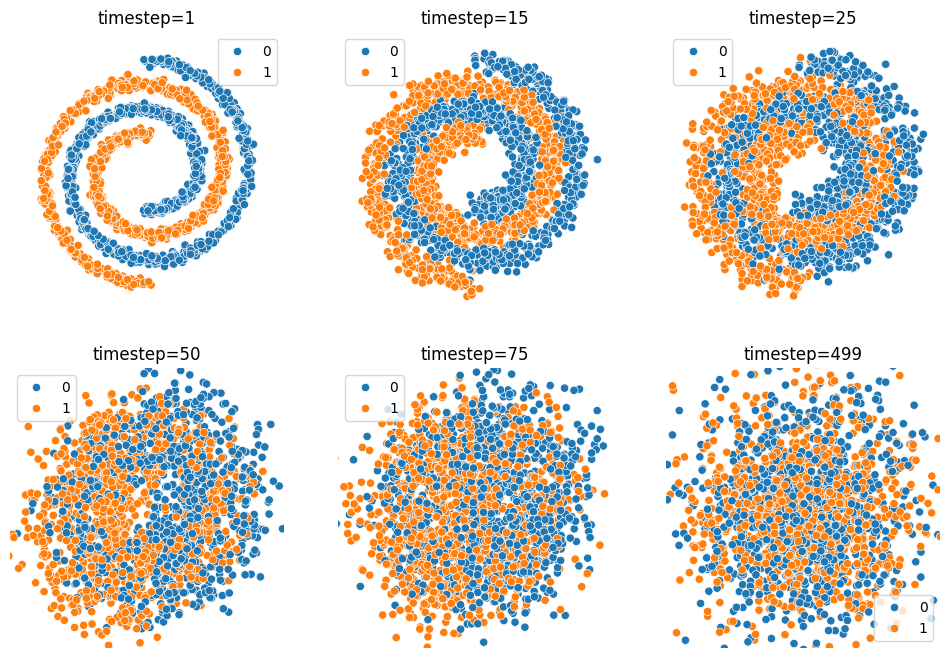

In [ ]:
# Посмотрим на прямой процесс диффузии, применённый к SwissRoll

T = 500
forward_diffusion = ForwardDiffusion(get_beta_schedule(T))

timesteps_to_plot = [1, 15, 25, 50, 75, 499]
n_plots = len(timesteps_to_plot)
ncols = 3
nrows = n_plots // ncols

_, axes = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(4 * ncols, 4 * nrows), squeeze=False)
for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j

        X_noised = forward_diffusion.q_sample(
            x0=th.from_numpy(X),
            t=th.ones_like(th.from_numpy(y)).long() * timesteps_to_plot[idx],
        )
        sns.scatterplot(x=X_noised[:, 0], y=X_noised[:, 1], hue=y, ax=axes[i, j])
        axes[i, j].set_title(f"timestep={timesteps_to_plot[idx]}")
        axes[i, j].set_xlim(-2.5, 2.5); axes[i, j].set_ylim(-2.5, 2.5)
        axes[i, j].set_axis_off()

### Реализуйте обратный процесс диффузии

In [ ]:
class ReverseDiffusion(BaseDiffusion):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.alphas_cumprod_prev = th.cat(
            [th.tensor([1.0], device=self.betas.device), self.alphas_cumprod[:-1]], dim=0
        )
        self.variance = (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod) * self.betas
        self.xt_coef = th.sqrt(self.alphas) * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.x0_coef = th.sqrt(self.alphas_cumprod_prev) * self.betas / (1.0 - self.alphas_cumprod)

        # ====

    def get_x0(self, xt: th.Tensor, eps: th.Tensor, t: th.Tensor) -> th.Tensor:
        broadcast_shape = xt.shape
        alphas_cumprod_t = _extract_into_tensor(self.alphas_cumprod, t, broadcast_shape)
        x0 = (xt - th.sqrt(1.0 - alphas_cumprod_t) * eps) / th.sqrt(alphas_cumprod_t)
        return x0

    def q_posterior_mean_variance(
        self, xt: th.Tensor, eps: th.Tensor, t: th.Tensor
    ) -> Tuple[th.Tensor, th.Tensor]:
        x0 = self.get_x0(xt, eps, t)
        broadcast_shape = xt.shape
        xt_coef = _extract_into_tensor(self.xt_coef, t, broadcast_shape)
        x0_coef = _extract_into_tensor(self.x0_coef, t, broadcast_shape)
        mean = xt_coef * xt + x0_coef * x0
        variance = _extract_into_tensor(self.variance, t, broadcast_shape)
        return mean, variance

    def p_sample(self, xt: th.Tensor, eps: th.Tensor, t: th.Tensor) -> th.Tensor:
        # прочитайте код для одного шага генерации внимательно
        mean, variance = self.q_posterior_mean_variance(xt=xt, eps=eps, t=t)
        noise = th.randn_like(xt, device=xt.device)

        nonzero_mask = th.ones_like(t) # чтобы не добавлять шум, если t = 0
        nonzero_mask[t == 0] = 0
        nonzero_mask = _extract_into_tensor(
            nonzero_mask, th.arange(nonzero_mask.shape[0]), xt.shape
        )
        nonzero_mask = nonzero_mask.to(xt.device)

        sample = mean + nonzero_mask * variance.sqrt() * noise
        return sample.float()

### Реализуем архитектуру нейронной сети для предсказания шума

In [ ]:
# Заметьте, что модель на вход принимает не только зашумлённый объект,
# но также момент времени и индекс класса.

class ConditionalMLP(nn.Module):
    def __init__(self, d_in: int, T: int, n_classes: int, hidden_dim: Optional[int]=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.x_proj = nn.Linear(d_in, self.hidden_dim)
        self.t_proj = nn.Embedding(T, self.hidden_dim)
        self.y_embed = nn.Embedding(n_classes, self.hidden_dim)
        self.backbone = nn.Sequential(
            nn.Linear(self.hidden_dim, 2 * self.hidden_dim),
            nn.GELU(),
            nn.Linear(2 * self.hidden_dim, d_in)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x, t, y):
        """
        Параметры:
        - x: зашумлённая картинка.
        - t: счётчик времени/уровень шума.
        - y: индекс класса, который нужно сгенерировать.
        """
        x = self.x_proj(x)
        t = self.t_proj(t.int())
        y = self.y_embed(y)
        x = x + t + y
        x = F.gelu(x)
        return self.backbone(x)

### Реализуйте DDPM

In [ ]:
class DDPM(nn.Module):
    def __init__(
        self,
        betas: th.Tensor,
        model: nn.Module,
        shape: Optional[Tuple[int, ...]] = None,
    ) -> None:
        super().__init__()

        self.forward_diffusion = ForwardDiffusion(betas=betas)
        self.reverse_diffusion = ReverseDiffusion(betas=betas)
        self.model = model
        self.num_timesteps = len(betas)
        self.shape = shape

        self.register_buffer("betas", betas)

    @property
    def device(self) -> None:
        return next(self.parameters()).device

    @th.no_grad()
    def sample(self, y: th.Tensor) -> th.Tensor:
        num_samples = y.shape[0]
        x = th.randn((num_samples, *self.shape), device=self.device, dtype=th.float32)
        indices = list(range(self.num_timesteps))[::-1]

        for i in tqdm(indices):
            t = th.tensor([i] * num_samples, device=x.device)
            eps = self.model(x, t, y)
            x = self.reverse_diffusion.p_sample(x, eps, t)
        return x, y

    def train_loss(self, x0: th.Tensor, y: th.Tensor) -> th.Tensor:
        if self.shape is None:
            self.shape = tuple(x0.shape[1:])
        t = th.randint(0, self.num_timesteps, size=(x0.size(0),), device=x0.device)
        noise = th.randn_like(x0)
        xt = self.forward_diffusion.q_sample(x0, t, noise)
        eps = self.model(xt, t, y)
        loss = F.mse_loss(eps, noise)
        return loss

In [ ]:
def save_checkpoint(model, optimizer, step, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'step': step,
    }, path)
    print(f"Сохранено: {path}")

def load_checkpoint(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    step = checkpoint['step']
    print(f"Загружено: {path} (step={step})")
    return step

In [ ]:
# Теперь давайте обучим наш DDPM.

def train_model(
    ddpm: DDPM,
    dataloader: DataLoader,
    *,
    lr: float,
    n_iters: int,
    device: str = "cpu",
    log_every: int = 500,
    save_every: int = 1000,
    checkpoint_path: str = None,
    resume: bool = False
):
    ddpm.to(device)
    optimizer = th.optim.Adam(ddpm.model.parameters(), lr=lr)
    step = 0

    if resume and checkpoint_path and os.path.exists(checkpoint_path):
        step = load_checkpoint(ddpm.model, optimizer, checkpoint_path, device=device)

    curr_loss_gauss = 0.0
    curr_count = 0
    optimizer.zero_grad()
    data_iter = iter(dataloader)
    while step < n_iters:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        x, y = batch["x"].to(device), batch["y"].to(device)

        loss = ddpm.train_loss(x, y)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        curr_count += len(x)
        curr_loss_gauss += loss.item() * len(x)

        if (step + 1) % log_every == 0:
            gloss = np.around(curr_loss_gauss / curr_count, 4)
            print(f"Step {(step + 1)}/{n_iters} Loss: {gloss}")
            curr_count = 0
            curr_loss_gauss = 0.0

        if checkpoint_path and (step + 1) % save_every == 0:
            save_checkpoint(ddpm.model, optimizer, step + 1, checkpoint_path)

        step += 1

    if checkpoint_path:
        save_checkpoint(ddpm.model, optimizer, step, checkpoint_path)

In [ ]:
T = 500
BATCH_SIZE = 1024
LR = 0.01
N_ITERS = 10000

model = ConditionalMLP(d_in=2, T=T, n_classes=2)
device = "cpu" # можно считать на гпу, но цпу должно быть достаточно

ddpm = DDPM(betas=get_beta_schedule(T), model=model, shape=(2,))
dataloader = get_labeled_data_loader(X, y, batch_size=BATCH_SIZE, shuffle=True)

train_model(
    ddpm=ddpm,
    dataloader=dataloader,
    lr=LR,
    n_iters=N_ITERS,
    device=device,
    checkpoint_path= f'{drive_root}/ddpm_checkpoint.pth',
    save_every=1000,
    resume=True,
)

Загружено: /content/drive/MyDrive/papadyk-collab/diffusion/ddpm_checkpoint.pth (step=10000)
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/ddpm_checkpoint.pth


100%|██████████| 500/500 [00:02<00:00, 170.54it/s]


Text(0.5, 1.0, 'real')

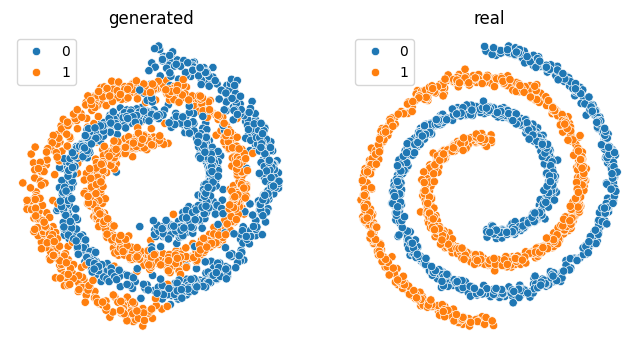

In [ ]:
# Теперь давайте посмотрим, что наша модель научилась генерировать (должно быть похоже на наш SwissRoll датасет)

num_samples = X.shape[0]
ys = th.randint(0, 2, size=(num_samples,), device=device)
Xs, ys = ddpm.sample(ys)

_, (ax_gen, ax_real) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
sns.scatterplot(x=Xs[:, 0].cpu().numpy(), y=Xs[:, 1].cpu().numpy(), hue=ys.cpu().numpy(), ax=ax_gen); ax_gen.set_axis_off();
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, ax=ax_real); ax_real.set_axis_off();

ax_gen.set_title("generated")
ax_real.set_title("real")

## Classifier-free guidance

К этому моменту мы реализовали базовый алгоритм для диффузионных моделей DDPM.

Теперь реализуем **classifier-free guidance** — технику для улучшения class-conditional генерации, которую мы разбирали на лекции.

Итоговая формула очень простая:
$$
\hat{\epsilon}_\theta(x_t, t, y) =
\epsilon_\theta(x_t, t, y=\varnothing)
+ s\bigl(\epsilon_\theta(x_t, t, y) - \epsilon_\theta(x_t, t, y=\varnothing)\bigr), \qquad (1)
$$
где:
- $\epsilon_\theta(x_t, t, y)$ — модель, которую мы обучаем;
- $s$ — guidance scale (контролирует силу guidance);
- $\hat{\epsilon}_\theta(x_t, t, y)$ — итоговая модель для предсказания шума;
- $y$ — класс, который мы хотим сгенерировать;
- $y = \varnothing$ означает, что в нейронную сеть подаётся специальный «пустой» класс для unconditional-режима.

**Обучение** происходит следующим образом:

1. Семплируем
   $$
   (x_0, c) \sim p_{\text{data}}, \quad
   t \sim \text{Uniform}\{1, \ldots, T\}, \quad
   \epsilon \sim \mathcal{N}(0, I).
   $$
2. Зашумляем данные:
   $$
   x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1 - \bar{\alpha}_t}\,\epsilon.
   $$
3. С вероятностью $p$ выбираем, учим ли мы модель в unconditional- или conditional-режиме:
   - unconditional:
     $$
     \|\epsilon_\theta(x_t, t, y=\varnothing) - \epsilon\|_2^2,
     $$
   - conditional:
     $$
     \|\epsilon_\theta(x_t, t, y=c) - \epsilon\|_2^2.
     $$

*Замечание.* Логика выбора unconditional-/conditional-режима обучения реализована за вас в классе `LabeledDataset` (лежит в `utils.py`). Это сделано затем, чтобы можно было переиспользовать функцию `train_model` без изменений. Обратите внимание на параметр `drop_label`.


### Реализуйте Classifier-free Guidance

In [ ]:
class DDPMWithCFG(DDPM):
    @th.no_grad()
    def sample_with_cfg(self, y: th.Tensor, guidance_scale: float=0., null_label: int=2):
        """
        Параметры:
        - y: метка класса;
        - guidance_scale:
            - 0: unconditional-режим;
            - 1: conditional-режим, честно восстанавливающий распределение;
            - чем выше значение, тем сильнее влияние класса;
        - null_label: заранее подготовленный индекс класса, отвечающий за unconditional-обучение.
        """
        assert self.shape is not None
        num_samples = y.shape[0]
        x = th.randn((num_samples, *self.shape), device=self.device, dtype=th.float32)
        indices = list(range(self.num_timesteps))[::-1]

        for i in tqdm(indices):
            t = th.tensor([i] * num_samples, device=x.device)
            eps_hat = self._predict_eps_hat(x, t, y, guidance_scale, null_label)
            x = self.reverse_diffusion.p_sample(x, eps_hat, t)
        return x, y

    def _predict_eps_hat(self, x: th.Tensor, t: th.Tensor, y: th.Tensor, guidance_scale: float, null_label: int):
        null_y = null_label * th.ones_like(y)
        eps_uncond = self.model(x, t, null_y)
        eps_cond = self.model(x, t, y)
        eps_hat = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        return eps_hat

In [ ]:
T = 500
BATCH_SIZE = 1024
LR = 0.01
N_ITERS = 30000
DROP_LABEL = 0.4

model = ConditionalMLP(d_in=2, T=T, n_classes=2+1)
device = "cpu" # можно считать на гпу, но цпу должно быть достаточно

ddpm = DDPMWithCFG(betas=get_beta_schedule(T), model=model, shape=(2,))
dataloader = get_labeled_data_loader(X, y, batch_size=BATCH_SIZE, shuffle=True, drop_label=DROP_LABEL)

train_model(
    ddpm=ddpm,
    dataloader=dataloader,
    lr=LR,
    n_iters=N_ITERS,
    device=device,
    checkpoint_path= f'{drive_root}/DDPMWithCFG_checkpoint.pth',
    save_every=1000,
    resume=True,
)

Загружено: /content/drive/MyDrive/papadyk-collab/diffusion/DDPMWithCFG_checkpoint.pth (step=30000)
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/DDPMWithCFG_checkpoint.pth


100%|██████████| 500/500 [00:06<00:00, 80.48it/s]


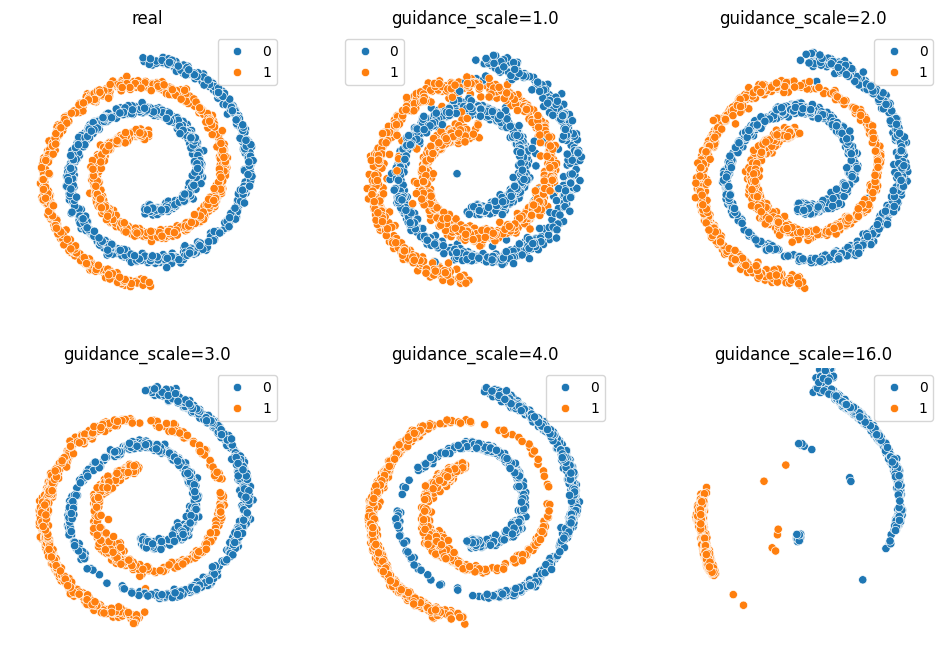

In [ ]:
# Давайте посмотрим на качество генерации c разным guidance scale

guidance_scale_to_plot = [1.0, 2.0, 3.0, 4.0, 16.0]
n_plots = len(guidance_scale_to_plot) + 1
ncols = 3
nrows = n_plots // ncols

num_samples = X.shape[0]
ys = th.randint(0, 2, size=(num_samples,), device=device)

_, axes = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(4 * ncols, 4 * nrows), squeeze=False)
for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j

        if idx == 0:
            sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, ax=axes[i, j])
            axes[i, j].set_title("real")
        else:
            idx = idx - 1
            Xs, ys = ddpm.sample_with_cfg(ys, guidance_scale=guidance_scale_to_plot[idx], null_label=2)
            sns.scatterplot(x=Xs[:, 0].cpu().numpy(), y=Xs[:, 1].cpu().numpy(), hue=ys.cpu().numpy(), ax=axes[i, j])
            axes[i, j].set_title(f"guidance_scale={guidance_scale_to_plot[idx]}")
        axes[i, j].set_xlim(-2.5, 2.5); axes[i, j].set_ylim(-2.5, 2.5)
        axes[i, j].set_axis_off()

**Замечания про classifier-free guidance:**
- генерирует семплы, которые более вероятны для конкретного класса (чем выше guidance scale, тем меньше пересечения между генерациями разных классов);
- слишком большой guidance scale может приводить к выбросам

## Ускоренный семплинг из DDPM

На данном этапе мы реализовали DDPM и технику classifier-free guidance.
В текущей реализации для генерации нужно делать столько же шагов, сколько вершин в марковской цепочке, а в случае использования classifier-free guidance — в два раза больше.
Это не критично для нашего игрушечного датасета SwissRoll, однако чем сложнее датасет и больше размерность данных, тем дороже становится каждый шаг генерации.

В этой части мы реализуем математически обоснованный способ пропускать некоторые вершины марковской цепочки для более быстрого семплинга из DDPM. Этот подход мы также обсуждали на лекции.

Вкратце вспомним, что там происходило.

Пусть у нас есть DDPM с максимальным индексом вершины в марковской цепочке $T$, и мы хотим семплировать за $I < T$ шагов.
При этом важно, чтобы мы могли переиспользовать предобученную на $T$ шагах диффузионную модель $\epsilon_\theta(x_t, t)$, где $t \in \{1, \ldots, T\}$.

Для этого мы искали более короткую марковскую цепочку длины $I$ (вершины будут проиндексированы $i \in \{1, \ldots, I\}$), которая является подцепочкой исходной более длинной:

1. Мы выбрали, каким вершинам исходной длинной цепочки будет соответствовать новая цепочка. Для этого мы задали функцию
   $\tau: \{1, \ldots, I\} \to \{1, \ldots, T\}$,
   которая отображает временные индексы новой цепочки в индексы старой. При этом важно, чтобы $\tau(I) = T$, чтобы новая цепочка всё так же заканчивалась в стандартном гауссовском распределении.

2. Далее мы формализовали наше желание, чтобы новая короткая цепочка была подцепочкой исходной. Для этого мы выровняли их соответствующие маргинальные распределения:
   $$
   q_{\text{new}}(x_i) = q(x_{t = \tau(i)}).
   $$

3. Это условие позволило нам найти параметры короткой диффузионной марковской цепочки:
   $$
   \beta_{\text{new}, i} = 1 - \alpha_{\text{new}, i}
   = 1 - \frac{\bar{\alpha}_{\tau(i)}}{\bar{\alpha}_{\tau(i - 1)}}. \qquad (1)
   $$

4. Также это позволило нам переиспользовать предобученную на длинной цепочке диффузионную модель $\epsilon_\theta(x_t, t)$:
   $$
   \epsilon_{\text{new}, \theta}(x_i, i) = \epsilon_\theta(x_t = x_i, t = \tau(i)). \qquad (2)
   $$

Таким образом, нам нужно сделать класс DDPM с правильными параметрами новой, более короткой марковской цепочки, определёнными выше, и корректным переиспользованием предобученной диффузионной модели, чтобы семплировать за $I < T$ шагов.


### Реализуйте WrappedModel и SpacedDDPMWithCFG

In [ ]:
class WrappedModel(nn.Module):
    """
    Класс обёртка для предобученной диффузионной модели epsilon(x_t, t),
        которая позволяет учитывать отображение tau счётчиков времени из нового в старый.

    Параметры:
    - model: предобученная диффузионная модель epsilon(x_t, t)
    - timestep_map: массив, который по индексу i содержит время tau(i)
    """
    def __init__(self, model: nn.Module, timestep_map: List):
        super().__init__()
        self.model = model
        self.timestep_map = timestep_map

    @property
    def device(self):
        return next(self.model.parameters()).device

    def forward(self, x: th.Tensor, t: th.Tensor, *args, **kwargs) -> th.Tensor:
        new_t = th.tensor([self.timestep_map[i.item()] for i in t], device=t.device, dtype=t.dtype)
        return self.model(x, new_t, *args, **kwargs)

In [ ]:
class SpacedDDPMWithCFG(DDPMWithCFG):
    """
    Класс для адаптации DDPM для более короткой марковской цепочки.
    Переопределяет параметры betas и использование нейронной сети.

    Параметры:
    - kwargs: параметры, которые задают обычный DDPM (длинную цепочку);
    - use_timesteps: массив индексов длинной цепочки, по которым мы хотели бы ходить.
    """

    def __init__(self, use_timesteps: Optional[Tuple]=None, **kwargs):
        # Если use_timesteps не задан, будем ходить по всем вершинам длинной цепочки
        if use_timesteps is None:
            use_timesteps = list(range(len(kwargs["betas"])))
        self.use_timesteps = set(use_timesteps)

        base_ddpm = DDPM(**kwargs)

        last_alpha_cumprod = 1.0
        new_betas = []
        for t, alpha_cumprod in enumerate(base_ddpm.forward_diffusion.alphas_cumprod):
            if t in self.use_timesteps:
                beta = 1.0 - (alpha_cumprod / last_alpha_cumprod)
                new_betas.append(beta.item() if hasattr(beta, "item") else float(beta))
                last_alpha_cumprod = alpha_cumprod
        kwargs = deepcopy(kwargs)
        kwargs["betas"] = th.tensor(new_betas)
        kwargs["model"] = WrappedModel(kwargs["model"], use_timesteps)
        super().__init__(**kwargs)

In [ ]:
# Вспомогательная функция, которая позволяет создать SpacedDDPMWithCFG по инстансу DDPM
# и задать количество шагов, которое мы хотим использовать.
# Эта функция распределяет шаги равномерно по вершинам (это частный случай и может быть неоптимален).

def get_spaced_ddpm(ddpm: DDPMWithCFG, num_timesteps: int=None):
    if num_timesteps is not None:
        num_timesteps = min(num_timesteps, ddpm.num_timesteps)
        use_timesteps = np.linspace(1, ddpm.num_timesteps, num=num_timesteps+1).astype("int")[1:]
    else:
        use_timesteps = None

    return SpacedDDPMWithCFG(
        use_timesteps=use_timesteps,
        betas=ddpm.betas,
        model=ddpm.model,
        shape=ddpm.shape,
    )

100%|██████████| 9/9 [00:00<00:00, 57.88it/s]


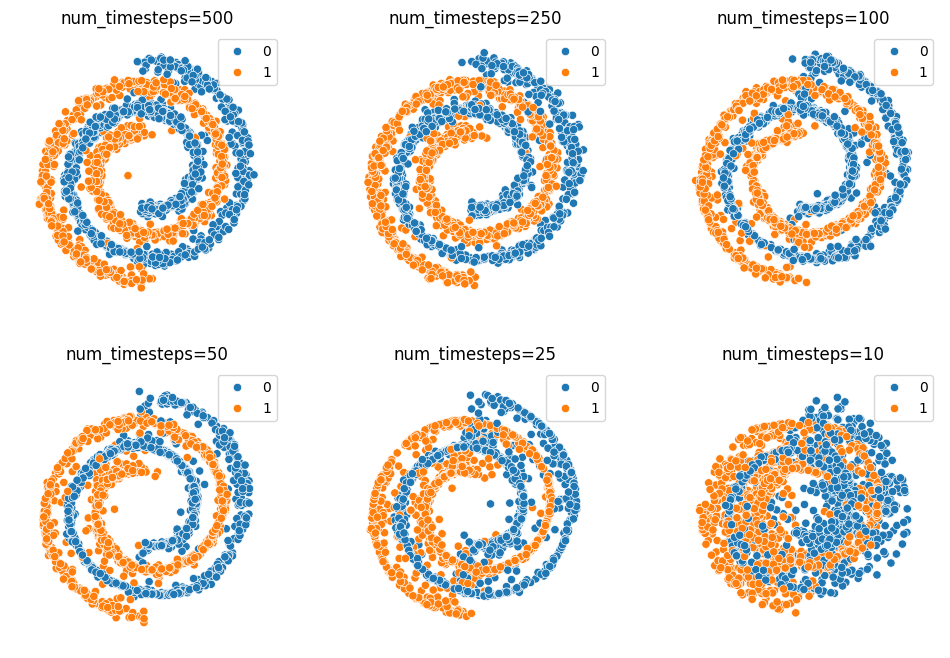

In [ ]:
# Давайте посмотрим на качество генерации при уменьшении количества шагов семплирования (guidance_scale = 1).

guidance_scale = 1.

num_timesteps_to_plot = [500, 250, 100, 50, 25, 10]
n_plots = len(num_timesteps_to_plot)
ncols = 3
nrows = n_plots // ncols

num_samples = X.shape[0]
ys = th.randint(0, 2, size=(num_samples,), device=device)

_, axes = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(4 * ncols, 4 * nrows), squeeze=False)
for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j

        spaced_ddpm = get_spaced_ddpm(ddpm, num_timesteps_to_plot[idx])
        Xs, ys = spaced_ddpm.sample_with_cfg(ys, guidance_scale=guidance_scale, null_label=2)
        sns.scatterplot(x=Xs[:, 0].detach().cpu().numpy(), y=Xs[:, 1].detach().cpu().numpy(), hue=ys.detach().cpu().numpy(), ax=axes[i, j])
        axes[i, j].set_title(f"num_timesteps={num_timesteps_to_plot[idx]}")
        axes[i, j].set_xlim(-2.5, 2.5); axes[i, j].set_ylim(-2.5, 2.5)
        axes[i, j].set_axis_off()

100%|██████████| 9/9 [00:00<00:00, 53.49it/s]


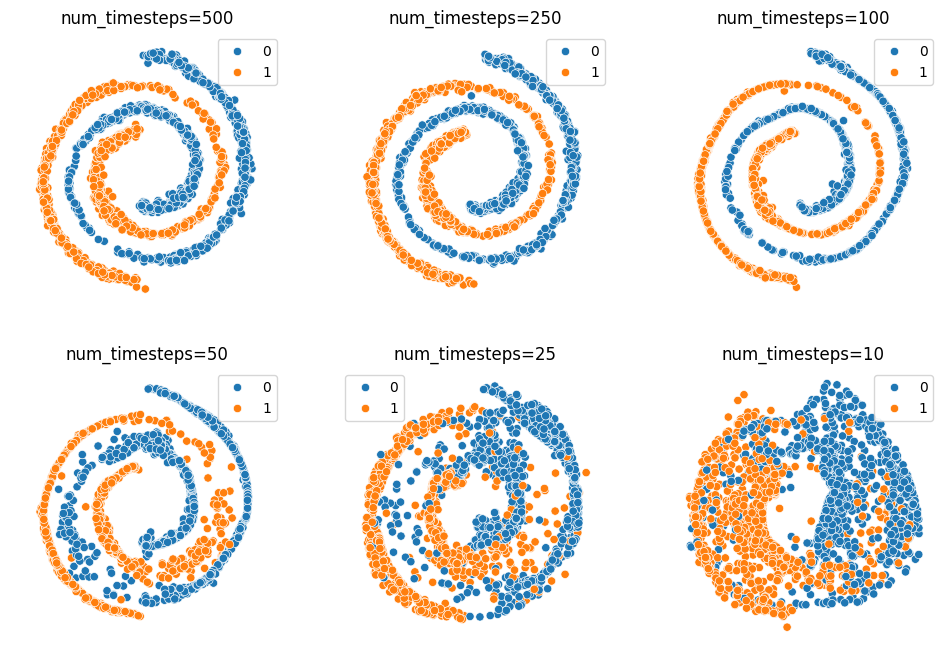

In [ ]:
# Давайте посмотрим на качество генерации при уменьшении количества шагов семплирования (guidance_scale = 3).
guidance_scale = 3

num_timesteps_to_plot = [500, 250, 100, 50, 25, 10]
n_plots = len(num_timesteps_to_plot)
ncols = 3
nrows = n_plots // ncols

num_samples = X.shape[0]
ys = th.randint(0, 2, size=(num_samples,), device=device)

_, axes = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(4 * ncols, 4 * nrows), squeeze=False)
for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j

        spaced_ddpm = get_spaced_ddpm(ddpm, num_timesteps_to_plot[idx])
        Xs, ys = spaced_ddpm.sample_with_cfg(ys, guidance_scale=guidance_scale, null_label=2)
        sns.scatterplot(x=Xs[:, 0].detach().cpu().numpy(), y=Xs[:, 1].detach().cpu().numpy(), hue=ys.detach().cpu().numpy(), ax=axes[i, j])
        axes[i, j].set_title(f"num_timesteps={num_timesteps_to_plot[idx]}")
        axes[i, j].set_xlim(-2.5, 2.5); axes[i, j].set_ylim(-2.5, 2.5)
        axes[i, j].set_axis_off()

Отлично! У нас получилось значительно сократить количество шагов генерации без особой потери в качестве!

## MNIST

В предыдущей части мы работали с двумерным датасетом SwissRoll.
Он может показаться слишком простым. Так и есть: именно из-за своей простоты он удобен для проверки и дебага нашего кода.

Теперь, когда мы видим, что наш код работает, протестируем его на чём-то посложнее — на MNIST!

In [ ]:
# Скачаем датасет

from torchvision.datasets.mnist import MNIST

def mnist_to_train_range(X):
    return ((X.astype("float32") / 255.) - 0.5) * 2

def mnist_from_train_range(X):
    return (((X.astype("float32") + 1.0) / 2) * 255.).astype("int")

dataset = MNIST("./datasets", download=True, train=True)
X = dataset.data.numpy().astype("float32")[:, None]
y = dataset.targets.numpy()
mnist_loader = get_labeled_data_loader(mnist_to_train_range(X), y, batch_size=64)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.68MB/s]


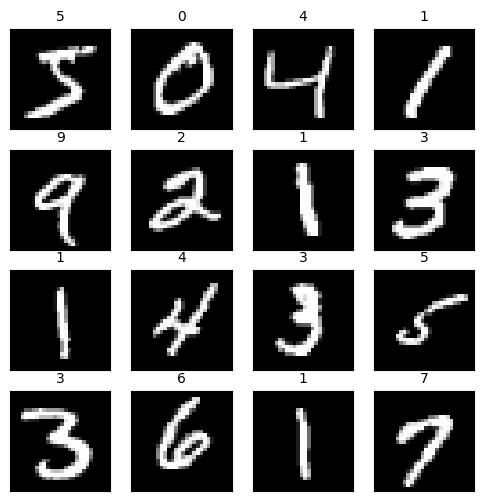

In [ ]:
# Вспомогательная функция для визуализации

def show_images(images, ys, title=""):
    if type(images) is th.Tensor:
        images = images.detach().cpu().numpy()
        ys = ys.detach().cpu().numpy()

    rows = int(len(images) ** (1 / 2))
    cols = round(len(images) / rows)
    fig = plt.figure(figsize=(cols*1.5, rows*1.5))

    idx = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, idx + 1)

            if idx < len(images):
                plt.imshow(images[idx][0], cmap="gray")
                plt.title(f"{int(ys[idx])}", fontsize=10)
                plt.tick_params(bottom = False, left=False, labelbottom=False, labelleft=False)
                idx += 1
    plt.show()

def show_first_batch(loader, batch_size=16):
    for batch in loader:
        show_images(batch["x"][:batch_size], batch["y"][:batch_size], "Images in the first batch")
        break

show_first_batch(mnist_loader)

### Визуализируйте прямой процесс диффузии

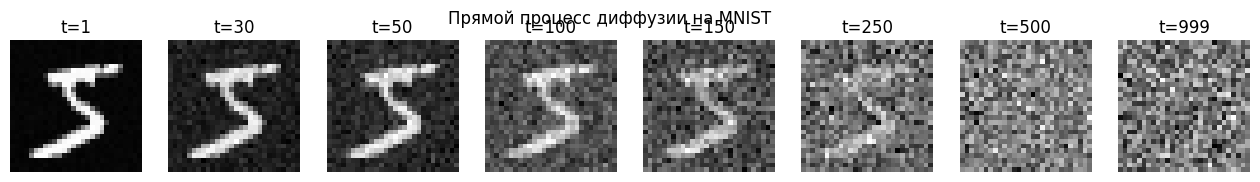

In [ ]:
T = 1000
forward_diffusion = ForwardDiffusion(get_beta_schedule(T))

timesteps_to_plot = [1, 30, 50, 100, 150, 250, 500, 999]

image = next(iter(mnist_loader))["x"][:1, 0]
image = image.to(th.float32)
image = image.to("cpu")

plt.figure(figsize=(16, 2))
for i, t in enumerate(timesteps_to_plot):
    t_tensor = th.tensor([t], dtype=th.long)
    # добавим размерность batch и channel
    img = image.unsqueeze(0)  # [1, 1, 28, 28]
    # применяем прямой процесс
    xt = forward_diffusion.q_sample(img, t_tensor)
    xt = xt.squeeze().detach().cpu().numpy()  # [28, 28]
    plt.subplot(1, len(timesteps_to_plot), i + 1)
    plt.imshow(xt, cmap="gray")
    plt.title(f"t={t}")
    plt.axis("off")
plt.suptitle("Прямой процесс диффузии на MNIST")
plt.show()

### Обучите диффузионную модель и получите хорошие генерации с помощью неё

In [ ]:
T = 1000
LR = 0.001
N_ITERS = 20000
DROP_LABEL = 0.2
BATCH_SIZE = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyUNet(use_null_cond=True)
ddpm = DDPMWithCFG(betas=get_beta_schedule(T), model=model, shape=(1, 28, 28))
dataloader = get_labeled_data_loader(mnist_to_train_range(X), y, batch_size=BATCH_SIZE, shuffle=True, drop_label=DROP_LABEL)

train_model(
    ddpm=ddpm,
    dataloader=dataloader,
    lr=LR,
    n_iters=N_ITERS,
    device=device,
    checkpoint_path= f'{drive_root}/MNIST_DDPMWithCFG_checkpoint.pth',
    save_every=1000,
    resume=True,
)

Загружено: /content/drive/MyDrive/papadyk-collab/diffusion/MNIST_DDPMWithCFG_checkpoint.pth (step=16000)
Step 16500/20000 Loss: 0.0259
Step 17000/20000 Loss: 0.0257
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/MNIST_DDPMWithCFG_checkpoint.pth
Step 17500/20000 Loss: 0.0256
Step 18000/20000 Loss: 0.0256
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/MNIST_DDPMWithCFG_checkpoint.pth
Step 18500/20000 Loss: 0.0256
Step 19000/20000 Loss: 0.0256
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/MNIST_DDPMWithCFG_checkpoint.pth
Step 19500/20000 Loss: 0.0253
Step 20000/20000 Loss: 0.0254
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/MNIST_DDPMWithCFG_checkpoint.pth
Сохранено: /content/drive/MyDrive/papadyk-collab/diffusion/MNIST_DDPMWithCFG_checkpoint.pth


100%|██████████| 1000/1000 [00:06<00:00, 149.14it/s]


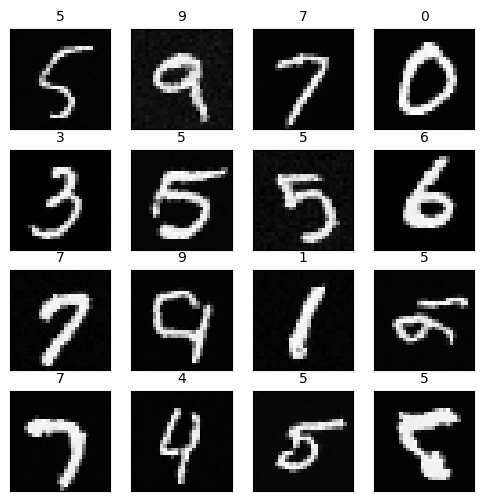

In [ ]:
# Теперь давайте посмотрим, что наша модель научилась генерировать

num_samples = 16
ys = th.randint(10, size=(num_samples,), device=device)
Xs, ys = ddpm.sample(ys)
show_images(Xs, ys)

### Сравните генерацию с помощью classifier-free с разными guidance scale

Сейчас для генерации в диффузионной модели нам нужно делать 1000 вызовов нейросети.

С classifier-free guidance потребуется 2000 вызовов.

Это долго, и с таким числом шагов сложно быстро экспериментировать.

Поэтому сначала подберём меньшее количество шагов семплирования без classifier-free guidance, при котором качество генерации остаётся хорошим, а затем будем использовать это количество шагов для сравнения разных значений guidance scale.

Используйте: `spaced_ddpm = get_spaced_ddpm(ddpm, ???)`


100%|██████████| 99/99 [00:02<00:00, 49.06it/s]


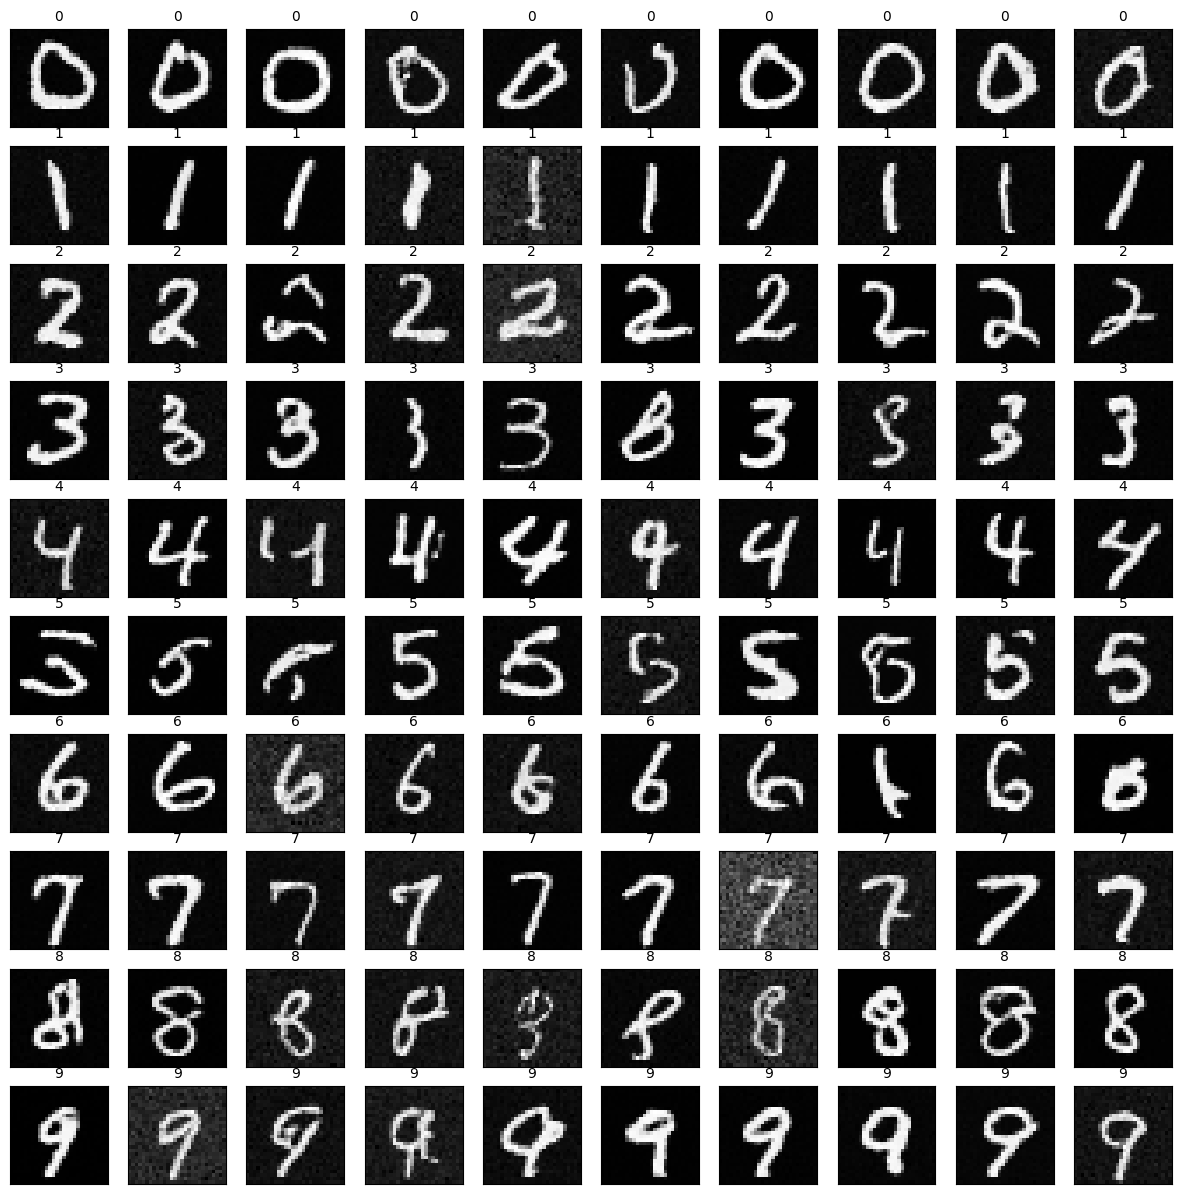

In [ ]:
n_steps = 100
spaced_ddpm = get_spaced_ddpm(ddpm, n_steps)

# Сгенерируем по 10 примеров для каждого класса
n_classes = 10
n_per_class = 10
y = th.arange(n_classes).repeat_interleave(n_per_class).to(ddpm.device)

# Генерация без guidance (guidance_scale=1)
with th.no_grad():
    samples, labels = spaced_ddpm.sample_with_cfg(y, guidance_scale=1.0, null_label=10)  # null_label зависит от вашей реализации

show_images(samples, labels, title=f"Spaced DDPM, n_steps={n_steps}, guidance_scale=1")

100%|██████████| 99/99 [00:01<00:00, 54.27it/s]


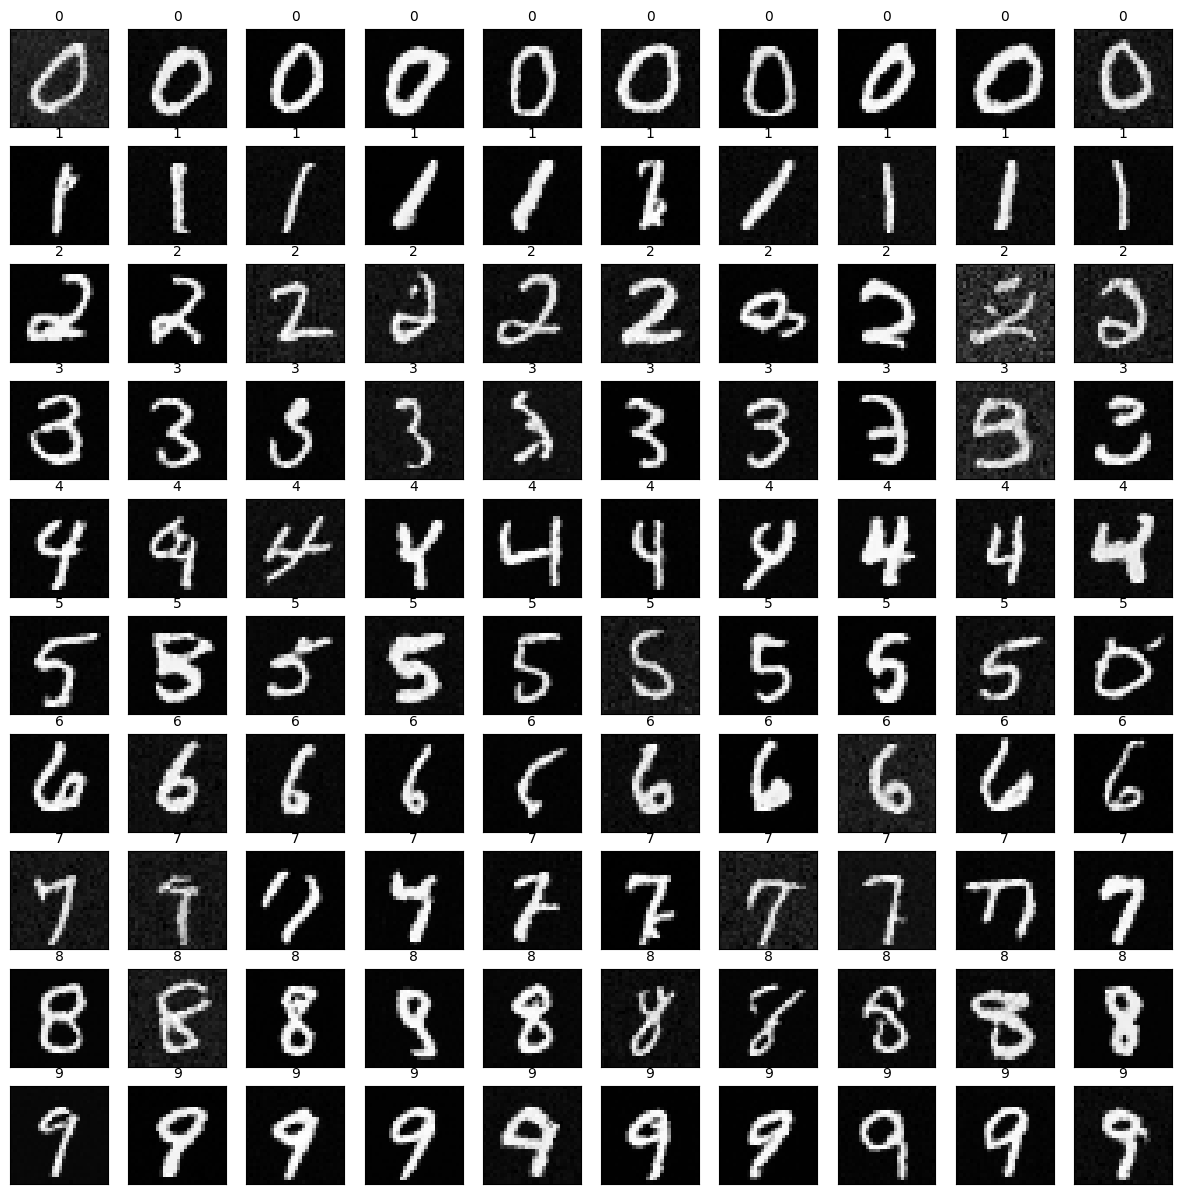

100%|██████████| 99/99 [00:02<00:00, 46.89it/s]


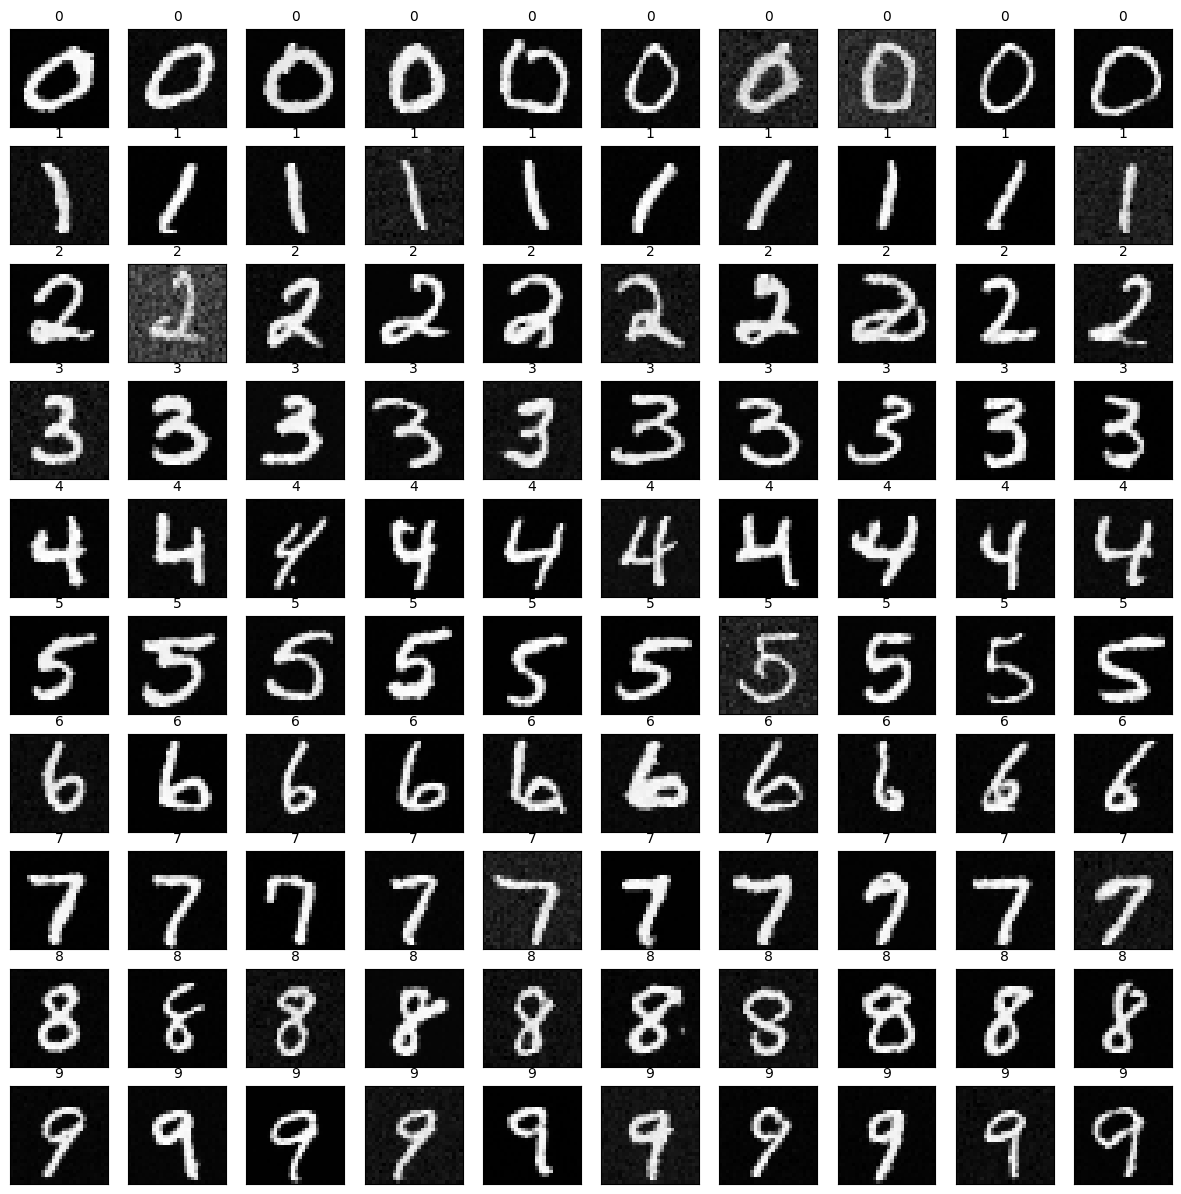

100%|██████████| 99/99 [00:01<00:00, 53.56it/s]


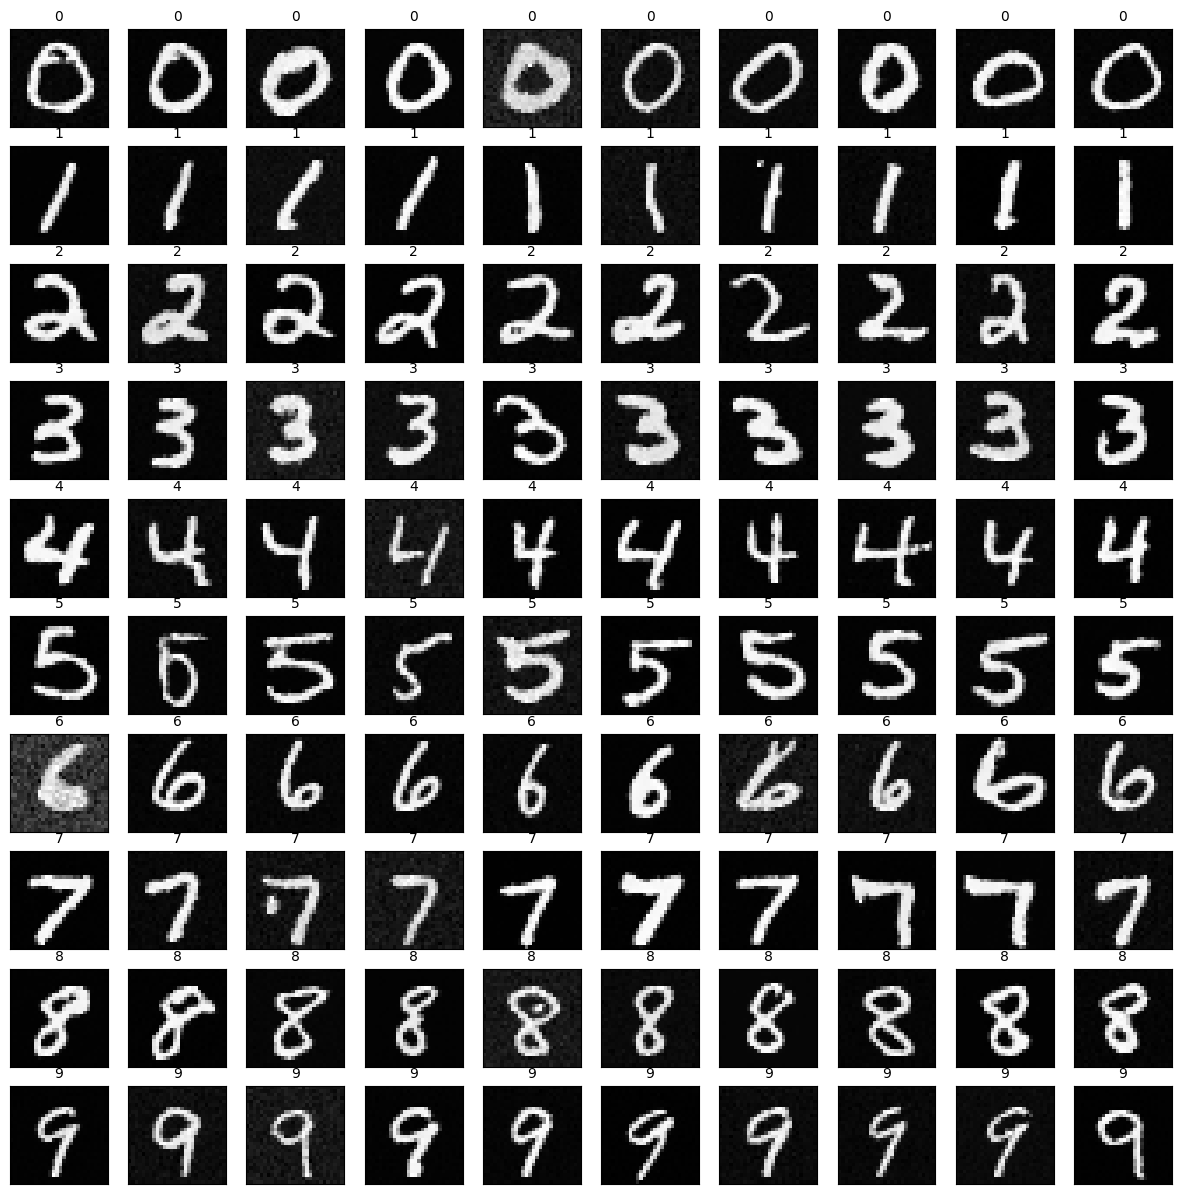

100%|██████████| 99/99 [00:02<00:00, 45.30it/s]


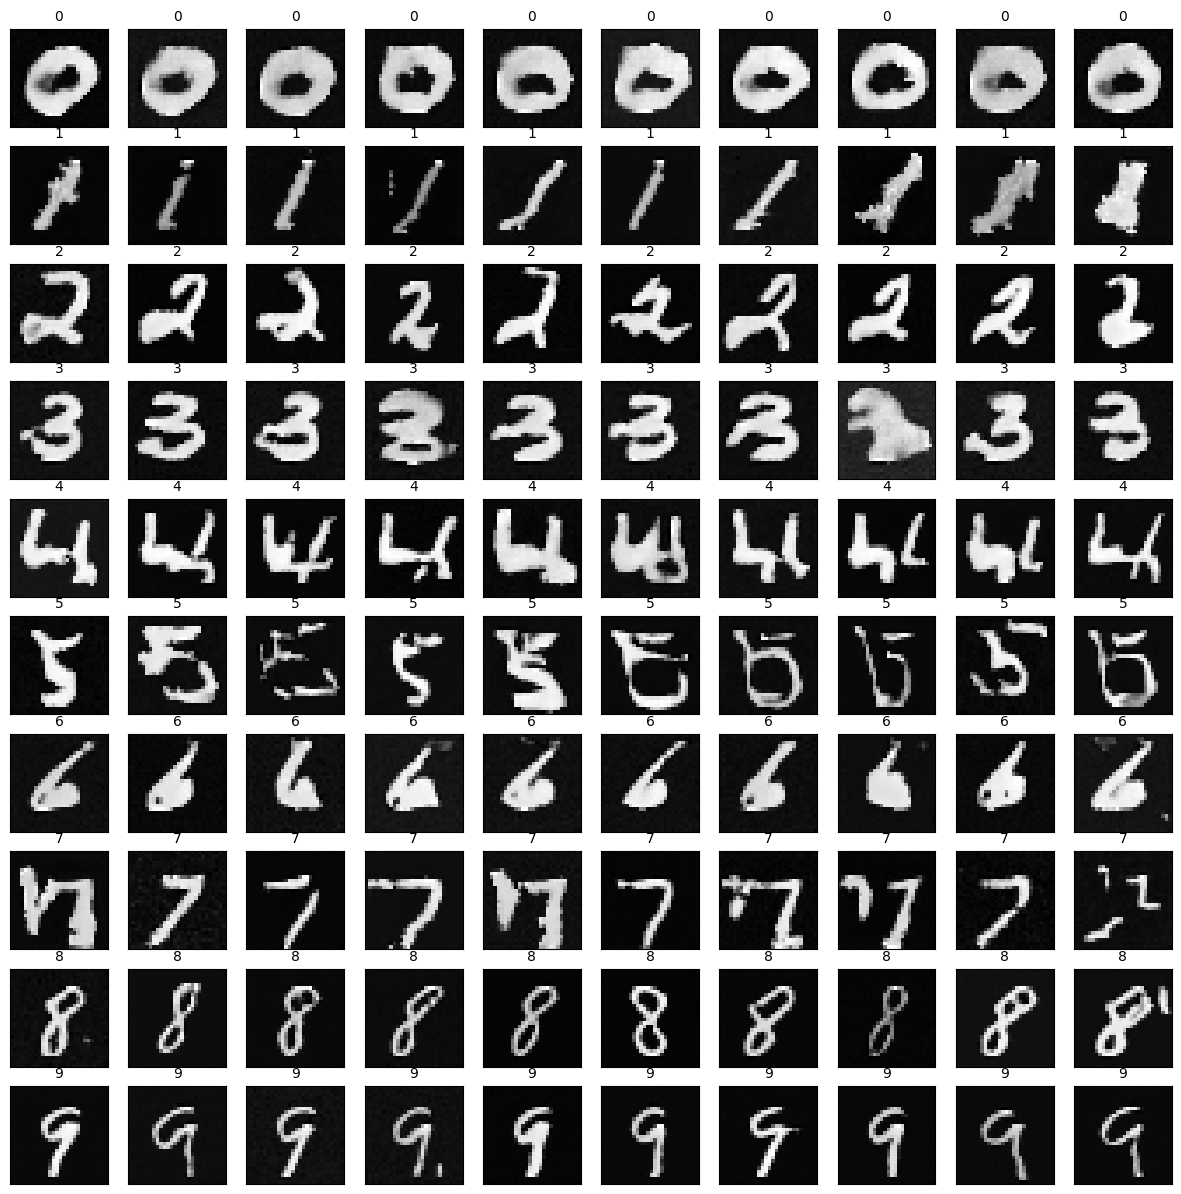

In [ ]:
guidance_scales = [1, 2, 4, 32]
for gs in guidance_scales:
    with th.no_grad():
        samples, labels = spaced_ddpm.sample_with_cfg(y, guidance_scale=gs, null_label=10)
    show_images(samples, labels, title=f"Spaced DDPM, n_steps={n_steps}, guidance_scale={gs}")